In [1]:
%%html
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@300;400;500;600;700&display=swap" rel="stylesheet">

<style>
/* markdown + output */
body, .markdown-body, .jp-RenderedHTMLCommon, div.text_cell_render,
.notebook, .notebook * {
  font-family: "Source Serif 4", serif !important;
}

/* code editor (monaco) */
.monaco-editor, .monaco-editor * {
  font-family: "Source Serif 4", serif !important;
}
</style>

### advanced statistical tests

this notebook covers chi-square tests, proportion tests, poisson rate tests, and variance tests used in statistical analysis.

In [151]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import norm, t, binom, poisson, expon, chi2, f
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels import stats as sm_stats
from statsmodels.stats import weightstats as sswa
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats import proportion as ssp
from statsmodels.stats.proportion import proportions_ztest
import os
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import chi2_contingency

In [152]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [153]:
# example: cdac mumbai vs pune engineers
# claim: mumbai has at least 12% more engineers than pune

# hypotheses:
# H₀: prop(mumbai) - prop(pune) >= 0.12 (claim)
# H₁: prop(mumbai) - prop(pune) < 0.12 (left tail test)

# data
# mumbai: 45 engineers out of 70 students
# pune: 60 engineers out of 100 students

engg = np.array([45, 60])
counts = np.array([70, 100])

# perform two-sample proportion test
z_stat, p_value = ssp.proportions_ztest(engg, counts, value=0.12, alternative='smaller')
print(f'z-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# calculate actual difference
actual_diff = (45/70) - (60/100)
print(f'\nactual difference: {actual_diff:.4f} ({actual_diff*100:.2f}%)')
print(f'claimed difference: 0.12 (12%)')

print(f'\ndecision:')
if p_value > 0.05:
    print('p-value > 0.05: fail to reject H₀')
    print('conclusion: claim that difference >= 12% is reasonable')
else:
    print('p-value < 0.05: reject H₀')
    print('conclusion: difference is less than 12%')

z-statistic: -1.0186
p-value: 0.1542

actual difference: 0.0429 (4.29%)
claimed difference: 0.12 (12%)

decision:
p-value > 0.05: fail to reject H₀
conclusion: claim that difference >= 12% is reasonable


---

### two-sample proportion test

**what it does:**
compares the proportions (percentages) between two groups to see if the difference is real or just by chance.

**when to use:**
- comparing success rates between two groups
- testing if proportion difference matches a claimed value
- example: comparing pass rates between two colleges

**how it works:**
- takes count of successes and total count from both groups
- tests if the difference between proportions is statistically significant

In [154]:
# example: car brand market share
# claimed pattern: 35%, 30%, 15%, 12%, 8% for 5 brands
# observed counts from sample

pattern = np.array([0.35, 0.30, 0.15, 0.12, 0.08])
obs_counts = np.array([120, 105, 80, 50, 30])

print(f'total observations: {sum(obs_counts)}')

total observations: 385


---

### chi-square goodness of fit test

**what it does:**
checks if observed data matches an expected pattern or distribution.

**when to use:**
- testing if data follows a claimed distribution
- comparing observed frequencies vs expected frequencies
- single categorical variable with multiple categories

**example:**
market share of car brands - does actual sales match claimed percentages?

In [155]:
# calculate expected counts based on pattern
exp_counts = pattern * sum(obs_counts)
print('expected counts based on claimed pattern:')
print(exp_counts)

expected counts based on claimed pattern:
[134.75 115.5   57.75  46.2   30.8 ]


In [156]:
# perform chi-square goodness of fit test
chi_stat, p_value = scipy.stats.chisquare(obs_counts, f_exp=exp_counts)

print(f'chi-square statistic: {chi_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'degrees of freedom: {len(obs_counts) - 1}')

print(f'\ndecision:')
if p_value < 0.05:
    print('p-value < 0.05: reject H₀')
    print('conclusion: observed counts do NOT match the claimed pattern')
else:
    print('p-value >= 0.05: fail to reject H₀')
    print('conclusion: observed counts match the claimed pattern')

chi-square statistic: 11.4750
p-value: 0.0217
degrees of freedom: 4

decision:
p-value < 0.05: reject H₀
conclusion: observed counts do NOT match the claimed pattern


In [157]:
# manual calculation: chi-square contribution from each category
# formula: (observed - expected)² / expected
ts_array = (obs_counts - exp_counts) ** 2 / exp_counts

print('chi-square contribution by category:')
for i, contribution in enumerate(ts_array):
    print(f'  category {i+1}: {contribution:.4f}')
    
print(f'\ntotal chi-square statistic: {sum(ts_array):.4f}')
print(f'category with highest contribution: {np.argmax(ts_array) + 1} (value: {max(ts_array):.4f})')

chi-square contribution by category:
  category 1: 1.6146
  category 2: 0.9545
  category 3: 8.5725
  category 4: 0.3126
  category 5: 0.0208

total chi-square statistic: 11.4750
category with highest contribution: 3 (value: 8.5725)


In [158]:
# example: equal preference test
# testing if all categories have equal preference

pattern = np.array([0.25, 0.25, 0.25, 0.25])
obs_count = np.array([5, 5, 5, 5])

exp_counts = sum(obs_count) * pattern

chi_stat, p_value = scipy.stats.chisquare(obs_count, exp_counts)
print(f'chi-square statistic: {chi_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'\nwith perfect equal distribution, chi-square = 0')

chi-square statistic: 0.0000
p-value: 1.0000

with perfect equal distribution, chi-square = 0


---

### chi-square test of independence

**what it does:**
tests if two categorical variables are related or independent of each other.

**when to use:**
- checking if choice in one variable depends on another variable
- testing association between two categorical variables
- example: does food preference depend on gender?

**how it works:**
- creates contingency table (cross-tabulation)
- compares observed frequencies with what we'd expect if variables were independent

In [159]:
# example: food preference vs gender
# H₀: food preference is independent of gender (no association)
# H₁: food preference depends on gender (association exists)

# contingency table:
#              veg    nonveg   fastfood
# male         110     150       40
# female       120      80       90

data = np.array([[110, 150, 40],   # male
                 [120, 80, 90]])    # female

print('observed data (contingency table):')
print('        veg  nonveg  fastfood')
print(f'male    {data[0,0]:3d}   {data[0,1]:3d}     {data[0,2]:3d}')
print(f'female  {data[1,0]:3d}    {data[1,1]:2d}      {data[1,2]:2d}')

observed data (contingency table):
        veg  nonveg  fastfood
male    110   150      40
female  120    80      90


In [160]:
# perform chi-square test of independence
chi_stat, p_value, dof, expected_freq = chi2_contingency(data)

print(f'\nchi-square statistic: {chi_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'degrees of freedom: {dof}')
print(f'  formula: (rows - 1) × (columns - 1) = (2-1) × (3-1) = {dof}')

print(f'\ndecision:')
if p_value < 0.05:
    print('p-value < 0.05: reject H₀')
    print('conclusion: food preference DEPENDS on gender (variables are associated)')
else:
    print('p-value >= 0.05: fail to reject H₀')
    print('conclusion: food preference is independent of gender')


chi-square statistic: 40.8121
p-value: 0.0000
degrees of freedom: 2
  formula: (rows - 1) × (columns - 1) = (2-1) × (3-1) = 2

decision:
p-value < 0.05: reject H₀
conclusion: food preference DEPENDS on gender (variables are associated)


In [161]:
# extract expected frequencies (what we'd expect if variables were independent)
exp_values = chi2_contingency(data)[3]

print('expected frequencies (if independent):')
print(exp_values)
print('\nthese are the counts we would expect if gender had no effect on food choice')

expected frequencies (if independent):
[[116.94915254 116.94915254  66.10169492]
 [113.05084746 113.05084746  63.89830508]]

these are the counts we would expect if gender had no effect on food choice


In [162]:
# manual calculation: chi-square contributions
# shows which cells contribute most to the association
ts = (exp_values - data)**2 / exp_values

print('chi-square contribution by cell:')
print(ts)
print(f'\ntotal chi-square statistic: {sum(sum(ts)):.4f}')
print('\nhigher values indicate cells where observed differs most from expected')

chi-square contribution by cell:
[[ 0.41292066  9.34045689 10.30682312]
 [ 0.4271593   9.66254161 10.66223081]]

total chi-square statistic: 40.8121

higher values indicate cells where observed differs most from expected


In [163]:
# example: accident rate test
# claim: accidents are limited to maximum 12 per day
# H₀: rate <= 12 per day
# H₁: rate > 12 per day (right tail test)

# data: 135 accidents in 10 days
# observed rate: 135/10 = 13.5 per day

observed_accidents = 135
time_period = 10  # days
claimed_rate = 12  # per day

observed_rate = observed_accidents / time_period
print(f'observed rate: {observed_rate:.2f} accidents per day')
print(f'claimed maximum rate: {claimed_rate} accidents per day')

observed rate: 13.50 accidents per day
claimed maximum rate: 12 accidents per day


---

### one-sample poisson rate test

**what it does:**
tests if the rate at which events occur matches a claimed rate.

**when to use:**
- testing event rates (accidents per day, calls per hour, defects per batch)
- count data where events occur randomly over time/space
- example: testing if accident rate exceeds safety limit

**key concept:**
rate = total events / time period

In [164]:
# perform poisson rate test
from statsmodels.stats.rates import test_poisson

z_stat, p_value = test_poisson(135, 10, 12, method='score', alternative='larger')

print(f'\nz-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

print(f'\ndecision:')
if p_value < 0.05:
    print('p-value < 0.05: reject H₀')
    print('conclusion: accident rate EXCEEDS 12 per day (claim violated)')
else:
    print('p-value >= 0.05: fail to reject H₀')
    print('conclusion: accident rate does not exceed 12 per day (claim holds)')


z-statistic: 1.3693
p-value: 0.0855

decision:
p-value >= 0.05: fail to reject H₀
conclusion: accident rate does not exceed 12 per day (claim holds)


In [165]:
# example: mumbai vs bangalore accident rates
# claim: mumbai has at least 4 more accidents per day than bangalore
# H₀: rate(mumbai) - rate(bangalore) >= 4
# H₁: rate(mumbai) - rate(bangalore) < 4 (left tail test)

# data:
# mumbai: 135 accidents in 10 days
# bangalore: 130 accidents in 15 days

mumbai_accidents = 135
mumbai_days = 10
bangalore_accidents = 130
bangalore_days = 15

mumbai_rate = mumbai_accidents / mumbai_days
bangalore_rate = bangalore_accidents / bangalore_days
actual_diff = mumbai_rate - bangalore_rate

print(f'mumbai rate: {mumbai_rate:.2f} accidents/day')
print(f'bangalore rate: {bangalore_rate:.2f} accidents/day')
print(f'actual difference: {actual_diff:.2f} accidents/day')
print(f'claimed difference: 4.0 accidents/day')

mumbai rate: 13.50 accidents/day
bangalore rate: 8.67 accidents/day
actual difference: 4.83 accidents/day
claimed difference: 4.0 accidents/day


---

### two-sample poisson rate test

**what it does:**
compares event rates between two groups to see if the difference is significant.

**when to use:**
- comparing accident rates between two cities
- comparing defect rates between two production lines
- testing if rate difference matches a claimed value

**formula:**
rate difference = (events₁ / time₁) - (events₂ / time₂)

In [166]:
# perform two-sample poisson rate test
from statsmodels.stats.rates import test_poisson_2indep

z_stat, p_value = test_poisson_2indep(135, 10, 130, 15, 
                                       value=4, 
                                       compare='diff', 
                                       method='score', 
                                       alternative='smaller')

print(f'\nz-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

print(f'\ndecision:')
if p_value < 0.05:
    print('p-value < 0.05: reject H₀')
    print('conclusion: difference is LESS than 4 accidents/day')
else:
    print('p-value >= 0.05: fail to reject H₀')
    print('conclusion: mumbai has at least 4 more accidents/day than bangalore')


z-statistic: 0.6064
p-value: 0.7279

decision:
p-value >= 0.05: fail to reject H₀
conclusion: mumbai has at least 4 more accidents/day than bangalore


---

### one-sample variance test (chi-square test)

**what it does:**
tests if population variance matches a claimed value using sample data.

**when to use:**
- testing consistency/variability of a process
- quality control - checking if variation is within acceptable limits
- example: testing if eruption time variability is as claimed

**key point:**
uses chi-square distribution because variance involves squared deviations.

In [167]:
# load geyser eruption data
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='faithful')
erupt = df.eruptions

print(f'sample size: {len(erupt)}')
print(f'sample mean: {np.mean(erupt):.4f} minutes')
print(f'sample std: {np.std(erupt, ddof=1):.4f} minutes')

sample size: 272
sample mean: 3.4878 minutes
sample std: 1.1414 minutes


In [168]:
# calculate sample variance
sample_var = np.var(erupt, ddof=1)
print(f'sample variance: {sample_var:.4f}')

sample variance: 1.3027


In [169]:
# for 95% confidence interval on variance (two-tailed)
# need chi-square critical values at 2.5% and 97.5%

n = len(erupt)
df_chi = n - 1

# lower critical value (2.5% tail)
chi_lower = scipy.stats.chi2.ppf(0.025, df_chi)
print(f'chi-square lower critical value (2.5%): {chi_lower:.4f}')
print(f'degrees of freedom: {df_chi}')

chi-square lower critical value (2.5%): 227.2931
degrees of freedom: 271


In [170]:
# upper critical value (97.5% percentile)
chi_upper = scipy.stats.chi2.ppf(0.975, df_chi)
print(f'chi-square upper critical value (97.5%): {chi_upper:.4f}')

chi-square upper critical value (97.5%): 318.4935


In [171]:
# calculate 95% confidence interval for variance
# formula: [(n-1)×s² / chi_upper, (n-1)×s² / chi_lower]

var_lower = (df_chi * sample_var) / chi_upper
var_upper = (df_chi * sample_var) / chi_lower

print(f'\n95% confidence interval for variance:')
print(f'lower bound: {var_lower:.4f}')
print(f'upper bound: {var_upper:.4f}')
print(f'sample variance: {sample_var:.4f}')

print(f'\ninterpretation:')
print(f'we are 95% confident that true population variance')
print(f'lies between {var_lower:.4f} and {var_upper:.4f}')


95% confidence interval for variance:
lower bound: 1.1085
upper bound: 1.5532
sample variance: 1.3027

interpretation:
we are 95% confident that true population variance
lies between 1.1085 and 1.5532


In [172]:
# convert to standard deviation confidence interval
std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

print(f'95% confidence interval for standard deviation:')
print(f'lower bound: {std_lower:.4f} minutes')
print(f'upper bound: {std_upper:.4f} minutes')
print(f'sample std: {np.std(erupt, ddof=1):.4f} minutes')

95% confidence interval for standard deviation:
lower bound: 1.0528 minutes
upper bound: 1.2463 minutes
sample std: 1.1414 minutes


---

### summary: when to use each test

#### proportion tests
- **one-sample:** testing if single proportion matches claimed value
- **two-sample:** comparing proportions between two groups

#### chi-square tests
- **goodness of fit:** testing if data matches expected distribution pattern
- **independence:** testing if two categorical variables are related

#### poisson rate tests
- **one-sample:** testing if event rate matches claimed rate
- **two-sample:** comparing event rates between two groups

#### variance tests
- **chi-square:** testing if variance/std deviation matches claimed value
- used for quality control and process consistency

---

1.	Do Urban and Rural stores differ in the variability of average customer spend?
2.	Does the distribution of UPI usage across the four bins (<40%, 40–50%, 50–60%, >60%) appear uniform?
3.	Is there a difference in UPI payment percentage between Urban and Rural stores?
4.	Do region and store location jointly influence footfall levels?
5.	Do Urban and Rural stores differ in the proportion of stores offering discounts?

In [173]:
df = pd.read_excel('data/MetroMart.xlsx')

In [174]:
pd.set_option('display.max_columns', None)    # showing every column

In [175]:
df.head()

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2


In [176]:
df.Location.value_counts().reset_index() # couting values from location

,Location,count
0,Urban,3254
1,Rural,1746


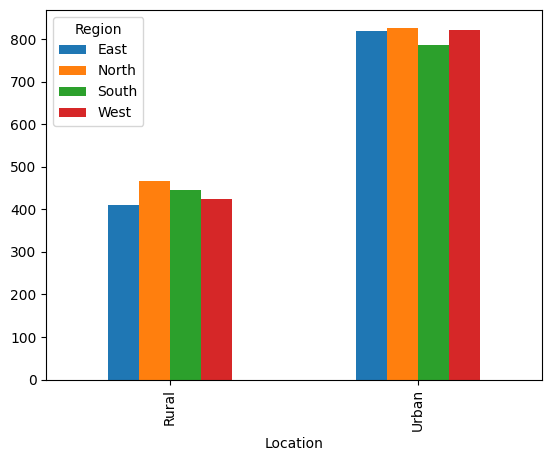

In [177]:
pd.crosstab(df.Location, df.Region).plot(kind='bar')
plt.show()

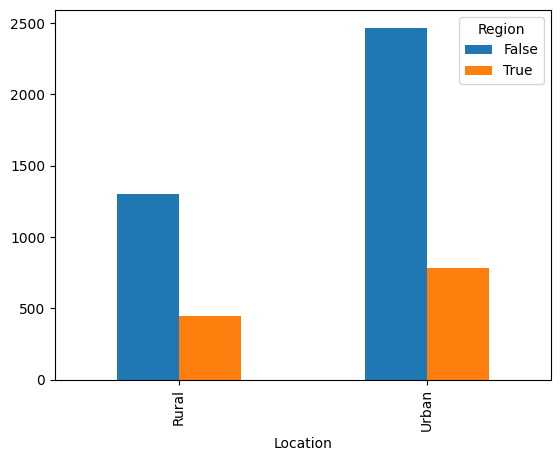

In [178]:
pd.crosstab(df.Location, df.Region=='South').plot(kind='bar')
plt.show()

In [179]:
df.iloc[np.where((df.Location == 'Urban') & (df.Region=='South') & (df.Promotion=='Discount'))]

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
9,Urban,South,889,552.81,5.18,4.65,108.35,Discount,53.7,28.2,4,2
27,Urban,South,914,569.61,5.15,4.79,118.65,Discount,50.9,39.6,5,5
29,Urban,South,976,555.28,5.54,4.97,123.92,Discount,50.0,41.8,4,1
36,Urban,South,954,535.53,5.53,5.03,117.19,Discount,39.4,42.0,5,5
39,Urban,South,889,599.80,5.25,4.69,117.30,Discount,49.2,38.1,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4912,Urban,South,943,593.49,4.99,4.55,126.76,Discount,42.4,33.2,4,6
4954,Urban,South,894,577.95,5.09,4.36,117.14,Discount,55.4,25.9,4,3
4971,Urban,South,958,591.91,5.30,4.92,125.34,Discount,41.8,44.9,4,0
4983,Urban,South,942,578.32,4.69,4.07,120.67,Discount,51.3,39.4,5,3


In [180]:
df.iloc[(df.Location.value_counts())]

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
3254,Rural,North,738,514.16,5.04,4.44,75.81,NoDiscount,55.6,37.1,2,8
1746,Rural,North,748,493.42,5.59,5.19,74.55,NoDiscount,61.2,21.6,3,4


In [181]:
bins = [0,4,9,14,18]

In [182]:
complaints_count = pd.cut(df.Complaints, bins = bins).value_counts().reset_index()

In [183]:
complaints_count

,Complaints,count
0,"(0, 4]",2996
1,"(4, 9]",1681
2,"(9, 14]",143
3,"(14, 18]",3


In [184]:
# 1.	Do Urban and Rural stores differ in the variability of average customer spend?

rural = df.Avg_Spend.iloc[np.where(df.Location=='Rural')]
urban = df.Avg_Spend.iloc[np.where(df.Location=='Urban' )]
f_ts=np.var(rural,ddof=1)/np.var(urban,ddof=1)
p_val = f.cdf(f_ts,len(rural)-1,len(urban)-1)
p_val*2

np.float64(0.8021795430179889)

In [185]:
df.head()

,Location,Region,Footfall,Avg_Spend,BillingTime_Before,BillingTime_After,MonthlySales,Promotion,Payment_UPI_pct,Payment_Card_pct,SatisfactionScore,Complaints
0,Rural,East,788,500.05,5.36,5.19,82.66,NoDiscount,54.6,17.6,3,3
1,Urban,South,978,580.24,5.06,4.58,121.61,NoDiscount,50.9,41.2,4,3
2,Urban,East,1018,565.95,4.94,4.21,123.26,NoDiscount,47.0,40.8,5,2
3,Urban,North,952,560.86,5.36,4.68,117.76,Discount,43.9,43.7,4,6
4,Rural,North,803,508.40,5.30,4.96,81.81,NoDiscount,58.5,27.5,4,2


In [186]:
# 2.	Does the distribution of UPI usage across the four bins (<40%, 40–50%, 50–60%, >60%) appear uniform?

In [187]:
upi = df.Payment_UPI_pct
upi_cats = pd.cut(df.Payment_UPI_pct, bins = [0,40,50,60,100]).value_counts()

In [188]:
upi_cats.values

array([1958, 1950,  895,  197])

In [189]:
obs_counts = upi_cats.values

In [190]:
exp_counts = np.array([1250,1250,1150,1352])

In [191]:
scipy.stats.chisquare(obs_counts, f_exp=exp_counts)

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
0.0004

In [ ]:
# 3. Is there a difference in UPI payment percentage between Urban and Rural stores?

In [ ]:
rural = df.Payment_UPI_pct.iloc[np.where(df.Location=='Rural')]
urban = df.Payment_UPI_pct.iloc[np.where(df.Location=='Urban')]

In [ ]:
np.mean(rural)

In [ ]:
np.mean(urban)

In [ ]:
counts = np.array([6003, 4806])
obs = np.array([10000,10000])

In [ ]:
ssp.proportions_ztest(counts, obs, value = 0, alternative='two-sided')

In [ ]:
# 4. Do region and store location jointly influence footfall levels?

In [ ]:
model = ols('df.Footfall~df.Location*df.Region', df).fit()

In [ ]:
res = sm.stats.anova_lm(model)

In [ ]:
res

In [ ]:
len(np.where((df.Location=='Urban')& (df.Promotion=='Discount'))[0])

In [ ]:
sswa.ztest(df.MonthlySales, value=95, alternative = 'smaller')

In [ ]:
np.mean(df.MonthlySales)

In [ ]:
sswa.ztest(df.MonthlySales, value = 115, alternative = 'smaller')

In [ ]:
sswa.ztest(df.MonthlySales, value = 105, alternative = 'smaller')

In [ ]:
# corrected: use sqrt(n) for standard error and fix column name typo
n = len(df.MonthlySales)
se = np.std(df.MonthlySales, ddof=1) / np.sqrt(n)
upper_95_one_sided = np.mean(df.MonthlySales) + 1.645 * se
upper_95_one_sided

In [ ]:
norm.ppf(0.05)

In [ ]:
# do urban and rural stores differ in their complaint rates?

In [ ]:
# 1.	Do Urban and Rural stores differ in the variability of average customer spend?
# 2.	Does the distribution of UPI usage across the four bins (<40%, 40–50%, 50–60%, >60%) appear uniform?
# 3.	Is there a difference in UPI payment percentage between Urban and Rural stores?
# 4.	Do region and store location jointly influence footfall levels?
# 5.	Do Urban and Rural stores differ in the proportion of stores offering discounts?
# 6.	Is the average monthly sales (in lakhs) across stores equal to ₹95?
# 7.	Has the new billing software reduced billing time per customer?
# 8.	Do stores in the North and South regions differ in their average monthly sales?
# 9.	Is the overall average complaint rate across stores equal to 4 complaints per store per month?
# 10.	Do Urban and Rural stores differ in their complaint rates?
# 11.	Is the proportion of stores offering discounts equal to 52%?
# 12.	Do Urban and Rural stores differ in the variability of card payment percentages?
# 13.	Is customer satisfaction category (Low/Medium/High) related to store location?

In [ ]:
# tasks 1-13: hypothesis tests on metromart data
results = {}

In [ ]:
# q1: variance difference in average spend (urban vs rural)
urban_spend = df.loc[df['Location'] == 'Urban', 'Avg_Spend'].dropna()
rural_spend = df.loc[df['Location'] == 'Rural', 'Avg_Spend'].dropna()
f_stat = np.var(urban_spend, ddof=1) / np.var(rural_spend, ddof=1)
df1, df2 = len(urban_spend) - 1, len(rural_spend) - 1
p_val = 2 * min(stats.f.cdf(f_stat, df1, df2), stats.f.sf(f_stat, df1, df2))
results['q1_variance_avg_spend'] = {'f_stat': f_stat, 'p_value': p_val}

In [ ]:
# q2: uniformity of upi usage bins
upi_bins = pd.cut(df['Payment_UPI_pct'], bins=[0, 40, 50, 60, 100], include_lowest=True)
upi_counts = upi_bins.value_counts().sort_index()
exp_counts = np.full(len(upi_counts), upi_counts.sum() / len(upi_counts))
chi_stat, chi_p = stats.chisquare(upi_counts, f_exp=exp_counts)
results['q2_upi_uniformity'] = {'chi2': chi_stat, 'p_value': chi_p}

In [ ]:
# q3: difference in upi percentage means (urban vs rural)
urban_upi = df.loc[df['Location'] == 'Urban', 'Payment_UPI_pct'].dropna()
rural_upi = df.loc[df['Location'] == 'Rural', 'Payment_UPI_pct'].dropna()
t_stat, t_p = stats.ttest_ind(urban_upi, rural_upi, equal_var=False)
results['q3_upi_mean_diff'] = {'t_stat': t_stat, 'p_value': t_p}

In [ ]:
# q4: two-way anova on footfall by region and location
anova_model = ols('Footfall ~ C(Location) * C(Region)', data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
results['q4_region_location_footfall'] = {
    'p_location': float(anova_table.loc['C(Location)', 'PR(>F)']),
    'p_region': float(anova_table.loc['C(Region)', 'PR(>F)']),
    'p_interaction': float(anova_table.loc['C(Location):C(Region)', 'PR(>F)'])
}

In [ ]:
# q5: discount proportion difference between urban and rural
is_discount = df['Promotion'].str.lower() == 'discount'
disc_counts = df.groupby('Location')['Promotion'].apply(lambda s: (s.str.lower() == 'discount').sum())
loc_totals = df['Location'].value_counts()
count_arr = np.array([disc_counts.get('Urban', 0), disc_counts.get('Rural', 0)])
nobs_arr = np.array([loc_totals.get('Urban', 0), loc_totals.get('Rural', 0)])
z_stat, z_p = proportions_ztest(count_arr, nobs_arr)
results['q5_discount_prop_diff'] = {'z_stat': float(z_stat), 'p_value': float(z_p)}

In [ ]:
# q6: monthly sales mean equals 95
sales = df['MonthlySales'].dropna()
t_stat, t_p = stats.ttest_1samp(sales, 95)
results['q6_monthly_sales_mean'] = {'t_stat': t_stat, 'p_value': t_p}

In [ ]:
# q7: billing time reduction after software (paired one-sided test)
before = df['BillingTime_Before'].dropna()
after = df.loc[before.index, 'BillingTime_After']
pair_stat, pair_p_two = stats.ttest_rel(before, after)
pair_p_one = pair_p_two / 2 if pair_stat > 0 else 1 - pair_p_two / 2
results['q7_billing_time_reduction'] = {'t_stat': pair_stat, 'p_value_one_sided': pair_p_one}

In [ ]:
# q8: north vs south monthly sales difference
north_sales = df.loc[df['Region'] == 'North', 'MonthlySales'].dropna()
south_sales = df.loc[df['Region'] == 'South', 'MonthlySales'].dropna()
t_stat, t_p = stats.ttest_ind(north_sales, south_sales, equal_var=False)
results['q8_north_south_sales'] = {'t_stat': t_stat, 'p_value': t_p}

In [ ]:
# q9: complaints mean equals 4
complaints = df['Complaints'].dropna()
t_stat, t_p = stats.ttest_1samp(complaints, 4)
results['q9_complaints_mean'] = {'t_stat': t_stat, 'p_value': t_p}

In [ ]:
# q10: complaints difference between urban and rural
urban_complaints = df.loc[df['Location'] == 'Urban', 'Complaints'].dropna()
rural_complaints = df.loc[df['Location'] == 'Rural', 'Complaints'].dropna()
t_stat, t_p = stats.ttest_ind(urban_complaints, rural_complaints, equal_var=False)
results['q10_complaints_diff'] = {'t_stat': t_stat, 'p_value': t_p}

In [ ]:
# q11: overall discount proportion equals 52%
is_discount = df['Promotion'].str.lower() == 'discount'
total_discounts = is_discount.sum()
n_total = len(is_discount)
z_stat, z_p = proportions_ztest(total_discounts, n_total, value=0.52)
results['q11_discount_rate_overall'] = {'z_stat': float(z_stat), 'p_value': float(z_p)}

In [ ]:
# q12: variance difference in card payment percentage
urban_card = df.loc[df['Location'] == 'Urban', 'Payment_Card_pct'].dropna()
rural_card = df.loc[df['Location'] == 'Rural', 'Payment_Card_pct'].dropna()
f_stat = np.var(urban_card, ddof=1) / np.var(rural_card, ddof=1)
df1, df2 = len(urban_card) - 1, len(rural_card) - 1
p_val = 2 * min(stats.f.cdf(f_stat, df1, df2), stats.f.sf(f_stat, df1, df2))
results['q12_card_variance'] = {'f_stat': f_stat, 'p_value': p_val}

In [ ]:
# q13: satisfaction category vs location (chi-square)
satisfaction_bins = pd.cut(df['SatisfactionScore'], bins=[0, 2.5, 3.5, 5.1], labels=['low', 'medium', 'high'])
cont_table = pd.crosstab(df['Location'], satisfaction_bins)
chi_stat, chi_p, _, _ = chi2_contingency(cont_table)
results['q13_location_vs_satisfaction'] = {'chi2': chi_stat, 'p_value': chi_p}

In [ ]:
results